In [1]:
import copy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely.affinity import affine_transform
from shapely.geometry import Point, LineString, Polygon, MultiPoint, MultiLineString, MultiPolygon, box
from geopandas import GeoSeries, GeoDataFrame
from shapely.ops import split, unary_union, polygonize
import pickle

/home/lxh/anaconda3/envs/urban3/lib/python3.9/site-packages/geopandas/_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [ ]:
NON_BLOCK_LAND_USE = (
    'outside',
    'feasible',
    'road',
    'boundary'
)

BLOCK_LAND_USE = (
    'residential',
    'business',
    'business_h',
    'green_l',
    'residential_h',
    'school',
    'hospital_l',
    'a2',
    'recreation'
)

LAND_USE = (
    NON_BLOCK_LAND_USE + BLOCK_LAND_USE)

OUTSIDE = 0
FEASIBLE = 1
ROAD = 2
BOUNDARY = 3
RESIDENTIAL = 4
BUSINESS = 5
BUSINESS_H = 6
GREEN_L = 7
residential_h = 8
SCHOOL = 9
HOSPITAL_L = 10
A2 = 11
RECREATION = 12


LAND_USE_ID = (
    OUTSIDE,
    FEASIBLE,
    ROAD,
    BOUNDARY,
    RESIDENTIAL,
    BUSINESS,
    BUSINESS_H,
    GREEN_L,
    residential_h,
    SCHOOL,
    HOSPITAL_L,
    A2,
    RECREATION,
)

BLOCK_LAND_TYPE = (
    RESIDENTIAL,
    BUSINESS,
    BUSINESS_H,
    GREEN_L,
    residential_h,
    SCHOOL,
    HOSPITAL_L,
    A2,
    RECREATION,
)

NUM_TYPES = len(LAND_USE_ID)

LAND_USE_ID_MAP = dict(
    zip(LAND_USE, LAND_USE_ID))

LAND_USE_ID_MAP_INV = dict(
    zip(LAND_USE_ID, LAND_USE))

INTERSECTION = 13

RESIDENTIAL_ID = (
    RESIDENTIAL
)

PUBLIC_SERVICES_ID = (
    BUSINESS,
    BUSINESS_H,
    SCHOOL,
    HOSPITAL_L, 
    A2,
    RECREATION
)

PUBLIC_SERVICES = (
    'shopping',
    'working',
    'education',
    'medical care',
    'a2'
    'entertainment'
)

GREEN_ID = (
    GREEN_L,
    RECREATION
)
GREEN_AREA_THRESHOLD = 5000

TYPE_COLOR_MAP = {
    'boundary': 'lightgreen',
    'business': '#e6005c',   # pink
    'feasible': 'white',
    'green_l': '#00ff00',
    'hospital_l': '#ff7f7e',    # light red
    'a2': 'darkred',
    'business_h': '#ff0000',    # red
    'outside': 'black',
    'residential': '#ffff2d',  # yellow
    'residential_h': 'gray',   # light yellow
    'road': '#a3a3a3',      # grey
    'school': '#ff85c9',   # light pink
    'recreation': '#acffcf',   # light blue
}

In [3]:
gdf_final= gpd.read_file('kq_final.geojson', driver='GeoJSON')

In [4]:
gdf_simplified = gdf_final

In [10]:
d = dict()
d['gdf'] = gdf_simplified
with open('./init_plan_kq.pickle', 'wb') as f:
    pickle.dump(d, f)

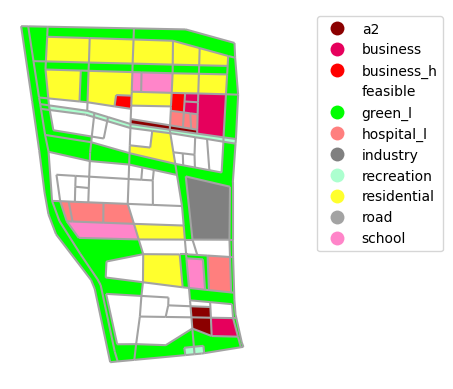

In [9]:
gdf_viz = copy.deepcopy(gdf_simplified[(gdf_simplified['existence'] == True) &
                                          (gdf_simplified['type'] != OUTSIDE) &
                                          (gdf_simplified['type'] != BOUNDARY) &
                                          (gdf_simplified['type'] != INTERSECTION)])
gdf_viz['legend'] = gdf_viz['type'].apply(lambda x: LAND_USE_ID_MAP_INV[x])
#gdf_viz = gdf_viz[gdf_viz.geom_type=='Polygon']
existing_types = sorted([LAND_USE_ID_MAP_INV[var] for var in gdf_viz['type'].unique()])
cmap = ListedColormap(
    [TYPE_COLOR_MAP[var] for var in existing_types])
gdf_viz.plot(
    'legend',
    cmap=cmap,
    categorical=True,
    legend=True,
    aspect=1,
    legend_kwds={'bbox_to_anchor': (1.8, 1)}
)
plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.show()